Planning window: 2025-06-30 to 2025-07-21
Horizon: 4 weeks


,Week,TV,Google Search,TikTok
0,2025-06-30 00:00:00,"$52,338","$61,550","$21,718"
1,2025-07-07 00:00:00,$0,"$37,156","$4,963"
2,2025-07-14 00:00:00,$0,"$36,198","$6,287"
3,2025-07-21 00:00:00,$0,"$34,564","$21,741"


,4-Week Baseline Spend ($),Additional Spend at +1% ($)
TV,"$52,338.27",$523.38
Google Search,"$169,467.82","$1,694.68"
TikTok,"$54,708.61",$547.09


Sampling: []


Output()

...

Output()

Sampling: []


Output()

,4-Week Baseline Spend ($),Additional Spend at +1% ($),Incremental Contribution 3% ($),Incremental Contribution Median ($),Incremental Contribution 97% ($),mROAS 3%,mROAS Median,mROAS 97%
Channel,,,,,,,,
TikTok,"$54,708.61",$547.09,$338.23,$631.28,$961.54,0.618,1.154,1.758
TV,"$52,338.27",$523.38,$322.66,$521.79,$734.61,0.616,0.997,1.404
Google Search,"$169,467.82","$1,694.68",$223.38,"$1,359.23","$2,889.60",0.132,0.802,1.705


Highest median 4-week marginal ROAS: TikTok (1.154x)


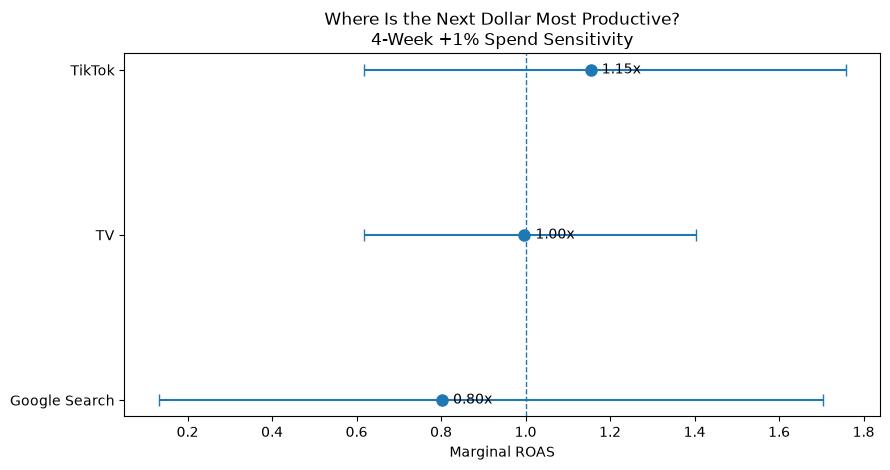

,+1% Spend,Median mROAS,3%,97%
Channel,,,,
TikTok,$547,1.15x,0.62x,1.76x
TV,$523,1.00x,0.62x,1.40x
Google Search,"$1,695",0.80x,0.13x,1.71x


In [2]:
# ============================================================
# 04a. Short-Term Marginal ROAS
# ============================================================
#
# Business question:
# Over the next 4 weeks, which channel is the most productive
# place for a small incremental investment?
#
# Method:
# 1. Use the first 4 weeks of the untouched test period as the
#    short-term spending plan.
# 2. Predict media contribution under that baseline plan.
# 3. Increase ONE channel's spend by 1% in all 4 weeks.
# 4. Re-predict media contribution.
# 5. Compute:
#
#       mROAS =
#       Incremental media contribution
#       --------------------------------
#       Incremental spend
#
# The analysis keeps the final training observations so that
# carryover from the historical period is included.
#
# Only contribution realized inside the 4-week planning window
# is counted. Carryover after week 4 is intentionally excluded
# because this is a short-term 4-week decision metric.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm.multidimensional import MMM


RANDOM_SEED = 20260801

HORIZON_WEEKS = 4
SPEND_INCREASE = 0.01

# In this project, spend and revenue are stored in $000s.
DOLLAR_SCALE = 1000.0

root = Path("..")

MODEL_PATH = root / "artifacts/mmm_regularized.nc"
TEST_PATH = root / "data/scenario_a/scenario_a_test.csv"

channel_columns = [
    "tv_spend",
    "google_search_spend",
    "tiktok_spend",
]

control_columns = [
    "promotion",
    "time_index",
]

names = {
    "tv_spend": "TV",
    "google_search_spend": "Google Search",
    "tiktok_spend": "TikTok",
}


# ============================================================
# 2. Load test data
# ============================================================

test_df = pd.read_csv(
    TEST_PATH,
    parse_dates=["date_week"],
)

test_df = (
    test_df
    .sort_values("date_week")
    .reset_index(drop=True)
)

assert len(test_df) >= HORIZON_WEEKS

plan_df = (
    test_df
    .iloc[:HORIZON_WEEKS]
    .copy()
)

X_baseline = plan_df[
    [
        "date_week",
        *channel_columns,
        *control_columns,
    ]
].copy()


print(
    "Planning window:",
    X_baseline["date_week"].min().date(),
    "to",
    X_baseline["date_week"].max().date(),
)

print(
    f"Horizon: {HORIZON_WEEKS} weeks"
)


# ============================================================
# 3. Inspect the actual 4-week baseline plan
# ============================================================

weekly_plan = (
    X_baseline[
        ["date_week", *channel_columns]
    ]
    .rename(
        columns={
            **names,
            "date_week": "Week",
        }
    )
    .copy()
)

for channel_name in names.values():
    weekly_plan[channel_name] *= DOLLAR_SCALE


display(
    weekly_plan.style.format(
        {
            "TV": "${:,.0f}",
            "Google Search": "${:,.0f}",
            "TikTok": "${:,.0f}",
        }
    )
)


four_week_spend = (
    X_baseline[channel_columns]
    .sum()
)

spend_summary = pd.DataFrame(
    {
        "4-Week Baseline Spend ($)": (
            four_week_spend * DOLLAR_SCALE
        ),
        "Additional Spend at +1% ($)": (
            four_week_spend
            * SPEND_INCREASE
            * DOLLAR_SCALE
        ),
    }
)

spend_summary.index = [
    names[channel]
    for channel in spend_summary.index
]

display(
    spend_summary.style.format(
        "${:,.2f}"
    )
)


# ============================================================
# 4. Helper: predict media contribution for a spending plan
# ============================================================

def predict_media_contribution(X_scenario):

    # Reload the same fitted model for every scenario
    model = MMM.load(MODEL_PATH)

    # channel_contribution IS an actual variable in the model graph
    prediction = model.sample_posterior_predictive(
        X=X_scenario,
        extend_idata=False,
        combined=True,
        include_last_observations=True,
        var_names=["channel_contribution"],
        random_seed=RANDOM_SEED,
    )

    contribution_scaled = prediction["channel_contribution"]

    # Convert contribution back to the original revenue scale.
    # For this additive MMM:
    #
    # contribution_original =
    # contribution_scaled * target_scale
    #
    target_scale = model.scalers["_target"]

    contribution_original = (
        contribution_scaled * target_scale
    )

    return contribution_original

# ============================================================
# 5. Baseline media contribution
# ============================================================

baseline_contribution = predict_media_contribution(
    X_baseline
)

print(
    "Contribution dimensions:",
    baseline_contribution.dims,
)

print(
    "Contribution shape:",
    baseline_contribution.shape,
)


# Sum over:
#   - all 4 weeks
#   - all 3 media channels
#
# Keep posterior sample uncertainty.

baseline_total_media = (
    baseline_contribution
    .sum(
        dim=[
            "date",
            "channel",
        ]
    )
)


# ============================================================
# 6. Run one +1% scenario for each channel
# ============================================================

results = []

scenario_contributions = {}
mroas_distributions = {}


for channel in channel_columns:

    # ----------------------------------------
    # Create the +1% spending scenario
    # ----------------------------------------

    X_plus = X_baseline.copy()

    X_plus[channel] = (
        X_plus[channel]
        * (1 + SPEND_INCREASE)
    )


    # ----------------------------------------
    # Exact additional spend
    # ----------------------------------------

    baseline_spend = (
        X_baseline[channel].sum()
    )

    scenario_spend = (
        X_plus[channel].sum()
    )

    additional_spend = (
        scenario_spend
        - baseline_spend
    )


    # Sanity check:
    # multiplying all four weeks by 1.01 must
    # increase total four-week spend by exactly 1%.
    assert np.isclose(
        additional_spend,
        SPEND_INCREASE * baseline_spend,
    )

    assert additional_spend > 0


    # ----------------------------------------
    # Predict media contribution
    # ----------------------------------------

    scenario_contribution = (
        predict_media_contribution(
            X_plus
        )
    )

    scenario_contributions[channel] = (
        scenario_contribution
    )


    # ----------------------------------------
    # Total 4-week media contribution
    # ----------------------------------------

    scenario_total_media = (
        scenario_contribution
        .sum(
            dim=[
                "date",
                "channel",
            ]
        )
    )


    # Ensure posterior samples are aligned
    baseline_aligned, scenario_aligned = (
        xr.align(
            baseline_total_media,
            scenario_total_media,
            join="exact",
        )
    )


    # ----------------------------------------
    # Incremental media contribution
    # ----------------------------------------

    incremental_contribution = (
        scenario_aligned
        - baseline_aligned
    )


    # ----------------------------------------
    # Marginal ROAS
    # ----------------------------------------
    #
    # numerator and denominator use the same
    # monetary scale, so the ratio is unitless.
    #
    # Example:
    # mROAS = 1.25
    #
    # means:
    # +$1 spend -> +$1.25 predicted media
    # contribution within these 4 weeks.
    # ----------------------------------------

    mroas = (
        incremental_contribution
        / additional_spend
    )

    mroas_samples = (
        np.asarray(mroas)
        .reshape(-1)
    )

    incremental_samples = (
        np.asarray(
            incremental_contribution
        )
        .reshape(-1)
    )


    mroas_distributions[channel] = (
        mroas_samples
    )


    # ----------------------------------------
    # Posterior summaries
    # ----------------------------------------

    mroas_low = np.quantile(
        mroas_samples,
        0.03,
    )

    mroas_median = np.quantile(
        mroas_samples,
        0.50,
    )

    mroas_high = np.quantile(
        mroas_samples,
        0.97,
    )


    incremental_low = np.quantile(
        incremental_samples,
        0.03,
    )

    incremental_median = np.quantile(
        incremental_samples,
        0.50,
    )

    incremental_high = np.quantile(
        incremental_samples,
        0.97,
    )


    results.append(
        {
            "Channel": names[channel],

            "4-Week Baseline Spend ($)":
                baseline_spend
                * DOLLAR_SCALE,

            "Additional Spend at +1% ($)":
                additional_spend
                * DOLLAR_SCALE,

            "Incremental Contribution 3% ($)":
                incremental_low
                * DOLLAR_SCALE,

            "Incremental Contribution Median ($)":
                incremental_median
                * DOLLAR_SCALE,

            "Incremental Contribution 97% ($)":
                incremental_high
                * DOLLAR_SCALE,

            "mROAS 3%":
                mroas_low,

            "mROAS Median":
                mroas_median,

            "mROAS 97%":
                mroas_high,
        }
    )


# ============================================================
# 7. Results table
# ============================================================

results_df = (
    pd.DataFrame(results)
    .set_index("Channel")
    .sort_values(
        "mROAS Median",
        ascending=False,
    )
)


display(
    results_df.style.format(
        {
            "4-Week Baseline Spend ($)":
                "${:,.2f}",

            "Additional Spend at +1% ($)":
                "${:,.2f}",

            "Incremental Contribution 3% ($)":
                "${:,.2f}",

            "Incremental Contribution Median ($)":
                "${:,.2f}",

            "Incremental Contribution 97% ($)":
                "${:,.2f}",

            "mROAS 3%":
                "{:.3f}",

            "mROAS Median":
                "{:.3f}",

            "mROAS 97%":
                "{:.3f}",
        }
    )
)


# ============================================================
# 8. Identify the highest median short-term mROAS
# ============================================================

best_channel = (
    results_df["mROAS Median"]
    .idxmax()
)

best_mroas = (
    results_df.loc[
        best_channel,
        "mROAS Median",
    ]
)

print(
    f"Highest median 4-week marginal ROAS: "
    f"{best_channel} ({best_mroas:.3f}x)"
)


# ============================================================
# 9. Presentation-ready mROAS chart
# ============================================================

plot_df = (
    results_df
    .sort_values(
        "mROAS Median",
        ascending=True,
    )
)

y = np.arange(
    len(plot_df)
)

median = (
    plot_df["mROAS Median"]
    .to_numpy()
)

lower = (
    plot_df["mROAS 3%"]
    .to_numpy()
)

upper = (
    plot_df["mROAS 97%"]
    .to_numpy()
)

xerr = np.vstack(
    [
        median - lower,
        upper - median,
    ]
)


fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

ax.errorbar(
    median,
    y,
    xerr=xerr,
    fmt="o",
    capsize=4,
    markersize=8,
)

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_yticks(
    y,
    plot_df.index,
)

ax.set_xlabel(
    "Marginal ROAS"
)

ax.set_title(
    "Where Is the Next Dollar Most Productive?\n"
    "4-Week +1% Spend Sensitivity"
)

for i, value in enumerate(median):
    ax.annotate(
        f"{value:.2f}x",
        xy=(value, i),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
    )

plt.tight_layout()
plt.show()


# ============================================================
# 10. Optional: clean table for the presentation
# ============================================================

presentation_table = (
    results_df[
        [
            "Additional Spend at +1% ($)",
            "mROAS Median",
            "mROAS 3%",
            "mROAS 97%",
        ]
    ]
    .copy()
)

presentation_table.columns = [
    "+1% Spend",
    "Median mROAS",
    "3%",
    "97%",
]

display(
    presentation_table.style.format(
        {
            "+1% Spend":
                "${:,.0f}",

            "Median mROAS":
                "{:.2f}x",

            "3%":
                "{:.2f}x",

            "97%":
                "{:.2f}x",
        }
    )
)